In [34]:
# 20 March 2025
# Zachary Katz
# zachary_katz@mines.edu

"""
Doppler width plot (spatial freq corrected for helicopter velocity) and crossover
analysis.
"""

# Imports and options
import os

import shapefile
import numpy as np
import xarray as xr
import scipy
import skimage


import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import cartopy.crs as ccrs
import matplotlib.patheffects as pe
from scipy.spatial import cKDTree
from scipy.optimize import curve_fit

%matplotlib inline

### MANUALLY SELECTED PARAMETERS ###
win_m = 750.0 # window length [m]
ovlp_m = 250.0 # overlap [m]

In [61]:
# Set paths and make output directory
offset_video_path_1819 = '../_Data/UTG_1819_OffsetVideo'
offset_video_path_1617 = '../_Data/UTG_1617_OffsetVideo'
lake_path = '../_Data/Ju_SLD2'
outdir = '.'
os.makedirs(outdir, exist_ok=True)

# Helper functions
def compute_doppler_spectrum(radargram, start_x, end_x):
    """
    Compute doppler spectrum of radargram using hilbert transform.

    Parameters
    ----------
    radargram : Xarray.Dataframe
        UTIG radargram offset video

    Returns
    -------
    doppler_spectrum : np.ndarray
        2D array of doppler spectrum 
    """
    
    # Example coordinates at the bed
    start_y = 1100
    end_y = 1800
    
    x_at = radargram['x'].compute().values  # meters
    x_at = x_at[:]
    y_at = radargram['y'].compute().values  # meters
    y_at = y_at[:]

    x_center = np.mean(x_at[start_x:end_x])
    y_center = np.mean(y_at[start_x:end_x])

    # Get low gain band
    dat = radargram['bxds2'].compute().astype(np.float32)
    
    # Hilbert along fast_time axis
    analytic = scipy.signal.hilbert(dat, axis=1)
    data = analytic.T

    # Fast fourier transform
    data_for_fft = data[start_y:end_y:,start_x:end_x]
    data_fft = np.fft.fftshift(np.fft.fft(data_for_fft, axis=1), axes=1)

    # Make frequency axis
    t = radargram['time'] 
    t_sec = (t - t[0]).astype('timedelta64[ns]').astype(np.float64) * 1e-9
    dt_slow = np.median(np.diff(t_sec.compute()))
    n_slow = data.shape[1]
    freq = np.fft.fftshift(
        np.fft.fftfreq(n_slow, d=dt_slow)
    )
    return freq, data_fft, start_y, end_y, x_center, y_center

def calc_doppler_ridge(freq, data_fft, start_y, end_y):
    """Use a Sato filter to extract the main band of a doppler spectrum.

    Parameters
    ----------
    freq : numpy.ndarray
        Frequency axis values of Fourier transform
    data_fft : numpy.ndarray
        2D fourier transform output
    start_y : float
        Starting y value of Fourier transform
    end_y : float
        Ending y value of Fourier transform

    Returns
    -------
    x : numpy.ndarray
        x-values of filtered maximum points at each frequency
    y : numpy.ndarray
        y-values of filtered maximum points at each frequency
    rad_db_sato : numpy.ndarray
        Sato-filtered and masked spectrum
    """

    # Transform radargram to log scale
    eps = 1e-20
    amp = np.abs(data_fft)  
    amp = amp / np.max(amp)
    rad_db = 20 * np.log10(amp + eps)

    # Filter for main band of spectrum and mask
    #rad_db = scipy.ndimage.gaussian_filter(rad_db, sigma=(3,2))
    rad_db = skimage.restoration.denoise_tv_chambolle(rad_db, weight=8)
    rad_db = skimage.filters.sato(rad_db, sigmas=range(10,30), black_ridges=False)
    mask = rad_db > (skimage.filters.threshold_otsu(rad_db))
    rad_db_sato = rad_db * mask

    max_indices = np.argmax(rad_db_sato, axis=0)
    x = np.linspace(freq[0], freq[-1], rad_db_sato.shape[1])
    return x, start_y + max_indices, rad_db_sato

def calc_width_and_max(x,y,threshold):
    """
    Find width and max of Sato-filtered doppler spectra.
    Start with y location of middle point, assumed to be in the main parabola 
    [valid unless severely sloping]. Work out in both directions until distance
    between point and prior point is greater than a threshold

    Parameters
    ----------
    x : numpy.ndarray
        x-values of filtered maximum points at each frequency
    y : numpy.ndarray
        y-values of filtered maximum points at each frequency
    threshold : float
        Gap tolerance in algorithm [ns]

    Returns
    -------
    x[right] : float
        Right edge x-value
    x[left] : float
        Left edge x-value
    x_at_max : float
        x-value at maximum y
    y_at_max : float
        Maximum y-value
    """

    y = -y # Flip direction convention (Depth increases downward)
    starting_index = np.argmin(np.abs(x))
    starting_point = y[starting_index]

    print(f"Initial starting point: {starting_point} at index {starting_index}")
    comp = -1110  # Lowest y value to consider
    if starting_point > comp:
        mask = np.abs(x - x[starting_index]) <= 500 # Look within 200 hz
        valid_mask = mask & (y < comp)
        
        if np.any(valid_mask):
            distances = np.abs(x[valid_mask] - x[starting_index])
            nearest_idx_within = np.argmin(distances)
            
            # Map back to original indices
            valid_indices = np.where(valid_mask)[0]
            chosen_index = valid_indices[nearest_idx_within]
            
            starting_point = y[chosen_index]
            starting_index = chosen_index
            print(f"Adjusted starting point: {starting_point} at index {starting_index}")
        else:
            return starting_index - 1, starting_index + 1, np.nan, np.nan

    start_point_left = starting_point
    start_index_left = starting_index

    # Find right edge
    threshold = 100  # ns
    diff = 0
    while (diff < threshold) and (starting_index < len(y)-1):
        next_index = starting_index + 1
        next_point = y[next_index]
        diff = np.abs(next_point - starting_point)
        starting_index = next_index
        starting_point = next_point

    right = (starting_index - 1)

    starting_index = start_index_left
    starting_point = start_point_left

    # Find left edge
    threshold = 100  # ns
    diff = 0
    while (diff < threshold) and (starting_index > 0):
        next_index = starting_index - 1
        next_point = y[next_index]
        diff = np.abs(next_point - starting_point)
        starting_index = next_index
        starting_point = next_point

    left = (starting_index + 1)

    y_masked = y[left:right]
    
    # Return nan if no max found
    try:
        y_at_max = -np.max(y_masked)
        x_at_max = x[np.argmax(y_masked) + left]
    except:
        y_at_max = np.nan
        x_at_max = np.nan

    return x[right],x[left], x_at_max, y_at_max

def plot_doppler(freq, data_fft, start_y, end_y, ridge_params, rad_db_sato):
    """
    Plot doppler spectrum and Sato-filtered doppler spectrum with max and width
    """

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Get doppler spectrum in dB
    eps = 1e-20
    amp = np.abs(data_fft)  
    amp = amp / np.max(amp)
    rad_db = 20 * np.log10(amp + eps)

    # Plot doppler spectrum
    im1 = ax1.imshow(rad_db, aspect='auto', cmap='gray', origin='lower', extent = [freq[0], freq[-1],start_y, end_y], vmin=-50, vmax=0)
    # Prettify ax1
    ax1.invert_yaxis()
    cb1 = fig.colorbar(im1, ax=ax1)
    ax1.set_ylabel("Fast Time [ns]",fontsize=16)
    ax1.set_xlabel("Doppler Frequency [Hz]",fontsize=16)
    ax1.tick_params(labelsize=14)
    cb1.ax.tick_params(labelsize=14)
    cb1.set_label("Amplitude [dB]", fontsize=16)

    # Plot Sato-filtered doppler spectrum
    im2 = ax2.imshow(rad_db_sato,aspect='auto', cmap='gray',origin='lower',extent = [freq[0], freq[-1],start_y, end_y])
   
    # Scatter maximum and width
    
    max_indices = np.argmax(rad_db_sato, axis=0)
    x = np.linspace(freq[0], freq[-1], rad_db_sato.shape[1])
    ax2.scatter(x, start_y + max_indices, color='red', s=10, marker='x')
    ax2.scatter(ridge_params['x_at_max'], ridge_params['y_at_max'], color='blue', s=100, marker='o')
    ax2.hlines(ridge_params['y_at_max'], ridge_params['left'], ridge_params['right'], colors='blue', linestyles='-', linewidth=2)
    
    # Prettify ax2
    ax2.invert_yaxis()
    cb2 = fig.colorbar(im2, ax=ax2, label="Amplitude [dB]")
    fig.tight_layout()
    ax2.set_ylabel("Fast Time [ns]",fontsize=16)
    ax2.set_xlabel("Doppler Frequency [Hz]",fontsize=16)
    ax2.tick_params(labelsize=14)
    cb2.ax.tick_params(labelsize=14)
    cb2.set_label("Sato [Thresholded]", fontsize=16)

    fig.tight_layout()
    return fig


def plot_radargram_planview_width(ax, xs_lake, ys_lake, plot_dict):
    """
    Plot doppler width and lake outline map view
    """

    bbox = [650000,-1475000,680000,-1430000] #David_SGL2_full extent

    # Remove borders
    ax.patch.set_facecolor("none")
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

    for x_center_list, y_center_list, plotting in zip(plot_dict['x_centers'], plot_dict['y_centers'], plot_dict['ridge_params_list']):
        width = [rp['right'] - rp['left'] for rp in plotting]
        cb = ax.scatter(x_center_list, y_center_list, c=width, cmap='viridis', s=30, zorder=4,vmin=0,vmax=25)

    for x, y in zip(xs_lake, ys_lake):
        ax.plot(x, y, color='white', linewidth=2.5, zorder=5)

    # Add colorbar
    k_cbar_anchor = (0,0)
    cbbox = inset_axes(ax, width=3,height=1,
                    bbox_to_anchor=k_cbar_anchor,
                    bbox_transform=ax.transAxes, loc="center left")
    [cbbox.spines[k].set_visible(False) for k in cbbox.spines]
    cbbox.tick_params(
        axis = 'both',
        left = False,
        top = False,
        right = False,
        bottom = False,
        labelleft = False,
        labeltop = False,
        labelright = False,
        labelbottom = False
    )
    cbbox.set_facecolor([0,0,0,0.9])

    cbaxes = inset_axes(cbbox, '92%', '20%', loc = 'center')
    cbar=fig.colorbar(cb,cax=cbaxes, orientation='horizontal',extend='max') #make colorbar
    cbar.outline.set_edgecolor('white')
    cbar.outline.set_linewidth(1)
    cbar.ax.tick_params(labelsize=14, color='white', labelcolor='white')
    cbar.set_label(r"Spatial Freq Width [m$^{-1}$]", fontsize=15, color='white')
    cbar.ax.xaxis.set_label_position('top')

    cbar.ax.minorticks_on()

    ax.set_xlim(bbox[0],bbox[2])
    ax.set_ylim(bbox[1],bbox[3])
    #ax.set_title(f"Window = {win_m} m, Overlap = {ovlp_m} m", fontsize=16)

    return fig

In [36]:
# Load KRT2 offset video netcdf files

file_paths_1819 = [os.path.join(offset_video_path_1819, f) for f in os.listdir(offset_video_path_1819) if f.endswith('.nc')]
file_paths_1617 = [os.path.join(offset_video_path_1617, f) for f in os.listdir(offset_video_path_1617) if f.endswith('.nc')]

offset_video_radargrams_1819 = []
for f in file_paths_1819:
    offset_video_radargram = xr.open_dataset(f, decode_timedelta=True)
    offset_video_radargrams_1819.append(offset_video_radargram)

offset_video_radargrams_1819.sort(key=lambda x: x.transect_id)
offset_video_radargrams_1819[0]

offset_video_radargrams_1617 = []
for f in file_paths_1617:
    offset_video_radargram = xr.open_dataset(f, decode_timedelta=True)
    offset_video_radargrams_1617.append(offset_video_radargram)

offset_video_radargrams_1617.sort(key=lambda x: x.transect_id)
offset_video_radargrams_1617[0]

len(offset_video_radargrams_1819), len(offset_video_radargrams_1617)


(42, 11)

In [40]:
# Select radargram
# Find radargram with transect id containing a certian Name
rad_no = 'GL1191'
for radargram in offset_video_radargrams_1617:
    if rad_no in radargram.transect_id:
        print(radargram.transect_id)
        test_rad = radargram
        break

"""
rad_no = 'X27b'
for radargram in offset_video_radargrams_1819:
    if rad_no in radargram.transect_id:
        print(radargram.transect_id)
        test_rad = radargram
        break
"""

avg_distance = np.mean(np.diff(test_rad['distance'].values))

time = (test_rad['time'][-1] - test_rad['time'][0])
time = time / np.timedelta64(1, 's')

velocity = (test_rad['distance'][-1] - test_rad['distance'][0]).values / time #m/s
test_rad['avg_velocity']  = velocity

dt = np.gradient(test_rad.time.values.astype('datetime64[ns]').astype('int64')) / 1e9 # seconds
dd = np.gradient(test_rad.distance.values) # meters
test_rad['velocity'] = (('distance',), dd/ dt) # m/s
  

DVG/IBH0c/GL1191a


In [41]:
def plot_doppler(freq, data, data_fft, start_y, end_y, ridge_params, rad_db_sato,start_x, end_x):
    """
    Plot doppler spectrum and Sato-filtered doppler spectrum with max and width
    """

    fig, axs = plt.subplots(2,2, figsize=(15,10))
    ax1, ax2, ax3, ax4 = axs.flatten()

    eps = 1e-20
    amp = np.abs(data)  
    amp = amp / np.max(amp)
    rad_db = 20 * np.log10(amp + eps)

    im1 = ax1.imshow(rad_db, aspect='auto', cmap='gray', origin='lower',vmin=-50, vmax=0)
    ax1.set_xlabel('Along-track Distance [m]', fontsize=14)
    ax1.set_ylabel('Fast Time [ns]', fontsize=14)
    ax1.tick_params(labelsize=12)
    ax1.invert_yaxis()

    # Add rectangle to show window used for doppler spectrum
    rect = plt.Rectangle((start_x, start_y), end_x - start_x, end_y - start_y, edgecolor='red', facecolor='none', linewidth=2)
    ax1.add_patch(rect)

    cb1 = fig.colorbar(im1, ax=ax1)
    cb1.ax.tick_params(labelsize=14)
    cb1.set_label("Amplitude [dB]", fontsize=16)

        
    # Get doppler spectrum in dB
    eps = 1e-20
    amp = np.abs(data_fft)  
    amp = amp / np.max(amp)
    rad_db = 20 * np.log10(amp + eps)

    # Plot doppler spectrum
    im2 = ax2.imshow(rad_db, aspect='auto', cmap='gray', origin='lower', extent = [freq[0], freq[-1],start_y, end_y], vmin=-50, vmax=0)
    # Prettify ax1
    ax2.invert_yaxis()
    cb2 = fig.colorbar(im2, ax=ax2)
    ax2.set_ylabel("Fast Time [ns]",fontsize=16)
    ax2.set_xlabel("Doppler Frequency [Hz]",fontsize=16)
    ax2.tick_params(labelsize=14)
    cb2.ax.tick_params(labelsize=14)
    cb2.set_label("Amplitude [dB]", fontsize=16)

    # Plot Sato-filtered doppler spectrum
    im3 = ax3.imshow(rad_db_sato,aspect='auto', cmap='gray',origin='lower',extent = [freq[0], freq[-1],start_y, end_y])

    # Prettify ax3
    ax3.invert_yaxis()
    cb3 = fig.colorbar(im3, ax=ax3, label="Amplitude [dB]")
    fig.tight_layout()
    ax3.set_ylabel("Fast Time [ns]",fontsize=16)
    ax3.set_xlabel("Doppler Frequency [Hz]",fontsize=16)
    ax3.tick_params(labelsize=14)
    cb3.ax.tick_params(labelsize=14)
    cb3.set_label("Sato [Thresholded]", fontsize=16)

    im4 = ax4.imshow(rad_db_sato,aspect='auto', cmap='gray',origin='lower',extent = [freq[0], freq[-1],start_y, end_y])
   
    # Scatter maximum and width

    max_indices = np.argmax(rad_db_sato, axis=0)
    x = np.linspace(freq[0], freq[-1], rad_db_sato.shape[1])
    ax4.scatter(x, start_y + max_indices, color='red', s=10, marker='x')
    ax4.scatter(ridge_params['x_at_max'], ridge_params['y_at_max'], color='blue', s=100, marker='o')
    ax4.hlines(ridge_params['y_at_max'], ridge_params['left'], ridge_params['right'], colors='blue', linestyles='-', linewidth=2)
    

    # Prettify ax4
    ax4.invert_yaxis()
    cb4 = fig.colorbar(im4, ax=ax4, label="Amplitude [dB]")
    fig.tight_layout()
    ax4.set_ylabel("Fast Time [ns]",fontsize=16)
    ax4.set_xlabel("Doppler Frequency [Hz]",fontsize=16)
    ax4.tick_params(labelsize=14)
    cb4.ax.tick_params(labelsize=14)
    cb4.set_label("Sato [Thresholded]", fontsize=16)

    ax_annotations = ['a.', 'b.', 'c.', 'd.']
    for ax, ax_annotation in zip(axs.flatten(), ax_annotations):
        ax.annotate(
        ax_annotation,
        xy=(-0.2, 1.1),
        xycoords='axes fraction',
        va='top',
        ha='left',
        color='black',
        fontsize=20,
        fontweight='bold'
        )   

    fig.tight_layout()
    return fig


In [59]:
# Make 4 panel figure S1
# Example doppler spectrum and width calculation
dat = test_rad['bxds2'].compute().astype(np.float32)
analytic = scipy.signal.hilbert(dat, axis=1)
data = analytic.T

starting_x_loc = 34500 # Note this is actually the 12000th index of the radargram. But because the radargram is sampled at 1m intervals (e.g., test_rad['distance'].plot()), this corresponds to 12000 m along track.
f_transform_width = 750

freq, data_fft, start_y, end_y, x_center, y_center = compute_doppler_spectrum(test_rad, starting_x_loc, starting_x_loc+f_transform_width)

# Find avg velocity in window
x_index_start = np.argmin(np.abs(test_rad['distance'].values - starting_x_loc))
x_index_end = np.argmin(np.abs(test_rad['distance'].values - (starting_x_loc+f_transform_width)))
avg_velocity = np.mean(test_rad['velocity'][x_index_start:x_index_end])
doppler_freq = np.array(freq) * float(avg_velocity)

x_sato, y_sato, sato_thresholded = calc_doppler_ridge(freq, data_fft, start_y, end_y)
right, left, x_at_max, y_at_max = calc_width_and_max(x_sato, y_sato, threshold=100)
right = right * float(avg_velocity)
left = left * float(avg_velocity)
x_at_max = x_at_max * float(avg_velocity)
ridge_params = {'right':right, 'left':left, 'x_at_max':x_at_max, 'y_at_max':y_at_max}


Initial starting point: -1452 at index 375


Initial starting point: -1452 at index 375


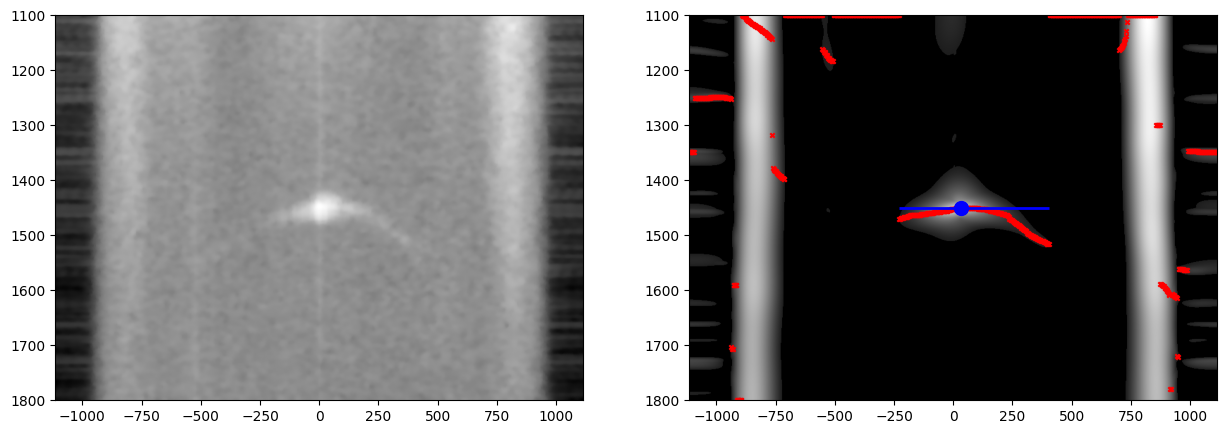

In [65]:
# Transform radargram to log scale
eps = 1e-20
amp = np.abs(data_fft)  
amp = amp / np.max(amp)
rad_db = 20 * np.log10(amp + eps)

# Filter for main band of spectrum and mask
#rad_db = scipy.ndimage.gaussian_filter(rad_db, sigma=(2,3))
rad_db = skimage.restoration.denoise_tv_chambolle(rad_db, weight=20)
#rad_db = skimage.restoration.denoise_bilateral(rad_db, sigma_color=0.01, sigma_spatial=3)
#rad_db = skimage.restoration.denoise_wavelet(rad_db, rescale_sigma=True)


rad_db_orig = rad_db.copy()

rad_db = skimage.filters.sato(rad_db, sigmas=range(10,30), black_ridges=False)
#rad_db = skimage.filters.meijering(rad_db, sigmas=range(10,20), black_ridges=False)
mask = rad_db > (skimage.filters.threshold_otsu(rad_db)-2)
rad_db_sato = rad_db * mask

max_indices = np.argmax(rad_db_sato, axis=0)
x = np.linspace(freq[0], freq[-1], rad_db_sato.shape[1])

x = np.array(x) * float(avg_velocity)
right, left, x_at_max, y_at_max = calc_width_and_max(x, start_y + max_indices, threshold=100)
ridge_params = {'right':right, 'left':left, 'x_at_max':x_at_max, 'y_at_max':y_at_max}


fig, (ax1,ax2) = plt.subplots(1,2, figsize=(15, 5))
im = ax1.imshow(rad_db_orig, aspect='auto', cmap='gray', origin='upper',extent = [x[0], x[-1],end_y, start_y])
im = ax2.imshow(rad_db_sato,aspect='auto', cmap='gray',origin='upper',extent = [x[0], x[-1],end_y, start_y])
# Plot ridge and width
ax2.scatter(x, start_y + max_indices, color='red', s=10, marker='x')
ax2.scatter(ridge_params['x_at_max'], ridge_params['y_at_max'], color='blue', s=100, marker='o')
ax2.hlines(ridge_params['y_at_max'], ridge_params['left'], ridge_params['right'], colors='blue', linestyles='-', linewidth=2)